# Monitoring ice velocity on Vega Island, Antarctica, using Sentinel-1 offset tracking

## Author: Moritz Rath

Geoprocessing with Python, Wintersemester 25/26, Geographisches Institut, Humboldt-Universität zu Berlin
Supervisors: Dr. Dirk Pflugmacher, Eduardo Ribeiro Lacerda

Hand-in due: April 15, 2026

**1. Import Packages**

In [1]:
import os
import ee
import geemap
import json
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
import re
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.dates import date2num, num2date
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

import FCK_ICE_fun as fun

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

path = 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data'


Successfully saved authorization token.


Import region shapefile for Vega Island

In [3]:
regionSHP = gpd.read_file(os.path.join(path, 'geodata/vega_island.shp'))
regionSHP = regionSHP.to_crs(epsg=4326)
regionSHP = regionSHP.drop(columns=['sourcedate', 'revdate'])
regionJS = regionSHP.to_json()
region = ee.FeatureCollection(json.loads(regionJS))

Get data from GEE

In [4]:
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD') \
      .filterBounds(region) \
      .filterDate('2020-01-01', '2025-01-01') \
      .filter(ee.Filter.eq('instrumentMode', 'IW')) \
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
      .filter(ee.Filter.eq('resolution_meters', 10)) \
      .select('HH') \
      .map(lambda img: img.set(
          'acq_date',
          ee.String(ee.String(img.get('system:index')).split('_').get(4)).slice(0, 8)
      )) \
      .sort('acq_date'))

In [ ]:
kwargs = {
    'grid_res': 200,
    'window_size': (256, 256),
    'path_out': 'auto',
    'fmt_out': 'GTIFF',
    'projectDir': 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister',
    'q' : True,
}

In [5]:
fun.coregisterS1(s1=s1, region=region, kwargs=kwargs)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200104.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200110.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200110.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200116.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200116.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200122.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200122.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\Tie_Point_Grid.py:1167: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200427.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200503.tif
Calculating tie point grid (128 points) using 8 CPU cores...
RANSAC skipped because too less valid tie points have been found.


c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\DeShifter.py:167: UserWarning: Only 3 valid tie point(s) could be identified. A local shift correction is therefore not reasonable and could cause artifacts in the output image. The target image is corrected globally with the mean X/Y shift of -0.174/0.121 pixels.
  warnings.warn(f'Only {len(self.GCPList)} valid tie point(s) could be identified. A local shift correction '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200503.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200509.tif
Calculating tie point grid (153 points) using 8 CPU cores...
RANSAC skipped because too less valid tie points have been found.


...

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221201.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221213.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221213.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221225.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221225.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20230106.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20230106.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\Tie_Point_Grid.py:1167: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240524.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240605.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240605.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240617.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240617.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240629.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240629.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\DeShifter.py:167: UserWarning: Only 2 valid tie point(s) could be identified. A local shift correction is therefore not reasonable and could cause artifacts in the output image. The target image is corrected globally with the mean X/Y shift of 0.213/0.270 pixels.
  warnings.warn(f'Only {len(self.GCPList)} valid tie point(s) could be identified. A local shift correction '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240828.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240909.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240909.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240921.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240921.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20241003.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20241003.tif
Generating URL ...
Please 

In [ ]:
demCOL = (ee.ImageCollection("UMN/PGC/REMA/V1/2m")\
          .filterBounds(region))
dem_mosaic = demCOL.reduce(ee.Reducer.min())
dem_mosaic = dem_mosaic.clip(region)

Retrieve the glacier mask maximum extent. We pin movement to this area to exclude movement in bedrock around the glaciers. 

In [10]:
rgi = ee.FeatureCollection("GLIMS/20230607") \
        .filterBounds(region)
gl = rgi.geometry().simplify(maxError=1)
glaciermask = gl.dissolve()
parts = ee.List(glaciermask.geometries())
fc_parts = ee.FeatureCollection(
    parts.map(lambda g:  ee.Feature(ee.Geometry(g)).set("area_m2", ee.Geometry(g).area(1)))
)

me = ee.Feature(fc_parts.sort("area_m2", False).first())
me_fc =ee.FeatureCollection([me])

out_shp = os.path.join(path, "geodata", "glacier_max_extent.shp")
geemap.ee_export_vector(me_fc, filename=out_shp)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\geodata\glacier_max_extent.shp


In [3]:
gm = gpd.read_file(os.path.join(path, "geodata", "glacier_max_extent.shp"))

# Rename the coregistered Images

In [4]:
path_coregister = r'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister'
renamed_df = fun.renameTifs(path_coregister, move=False, recursive=True)
meta = pd.DataFrame(renamed_df, columns=["src", "dst"])

date_re = re.compile(r"(\d{8})__shifted_to__(\d{8})", re.IGNORECASE)
dates = meta["src"].str.extract(date_re)
meta["date1"] = pd.to_datetime(dates[0], format="%Y%m%d")
meta["date2"] = pd.to_datetime(dates[1], format="%Y%m%d")
meta["mid_date"] = meta["date1"] + (meta["date2"]-meta["date1"]) / 2
meta["delta_days"] = (meta["date2"] - meta["date1"]).dt.days

meta = meta.sort_values("mid_date").reset_index(drop=True)

Load Tifs

In [ ]:
tif_paths = [Path(p) for p in meta["dst"]]
tifs = [rasterio.open(p) for p in tif_paths]

Single means and velocity interpolation

In [6]:
try:
    masked_arrays, template = fun.maskTif_loop(tifs, regionSHP, gm, crop=False,
                                               write=False,
                                               out_dir="C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/masked")
finally:
    for ds in tifs:
        ds.close()

In [7]:
disp_m = []
for arr in masked_arrays:
    a = np.squeeze(arr).astype("float32")
    a[a==template["nodata"]] = np.nan
    disp_m.append(np.nanmean(np.abs(a)))

meta["displacement_m"] = disp_m
meta["velocity_m_d"] = meta["displacement_m"] / meta["delta_days"]
meta[["mid_date", "delta_days", "displacement_m", "velocity_m_d"]].head()

,mid_date,delta_days,displacement_m,velocity_m_d
0,2020-01-07,6,17.209114,2.868186
1,2020-01-13,6,14.717775,2.452963
2,2020-01-19,6,13.791815,2.298636
3,2020-01-25,6,12.290565,2.048428
4,2020-01-31,6,14.134783,2.355797


In [8]:
velocity_series = pd.Series(
    meta["velocity_m_d"].values, 
    index=pd.to_datetime(meta["mid_date"])
).sort_index()

daily_index = pd.date_range(
    velocity_series.index.min().floor("D"),
    velocity_series.index.max().ceil("D"),
    freq="D"
)

daily_velocity = (
    velocity_series
    .reindex(daily_index)
    .interpolate("time")
    .ffill()
    .bfill()
)

daily_velocity.name = "velocity_m_d"

# Trend analysis (TSA)


Preparing and conducting a single day TSA

In [9]:
monthly_velocity = daily_velocity.resample("M").median()
monthly_velocity.name = "monthly_velocity_m_day"

C:\Users\morit\AppData\Local\Temp\ipykernel_18240\3494978551.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_velocity = daily_velocity.resample("M").median()


In [13]:
monthly_df = monthly_velocity.dropna().to_frame()
monthly_df["t"] = np.arange(len(monthly_df), dtype=float)
monthly_df["month"] = monthly_df.index.month
monthly_df["doy"] = monthly_df.index.dayofyear.astype(float)

X = pd.DataFrame({"t": monthly_df["t"]})
K=2
for k in range(1, K+1):
    X[f"sin{k}"] = np.sin(2 * np.pi *k * monthly_df["doy"] / 365.25)
    X[f"cos{k}"] = np.cos(2 * np.pi *k * monthly_df["doy"] / 365.25)

X = sm.add_constant(X)
y = monthly_df["monthly_velocity_m_day"].astype(float).values

model = sm.OLS(y, X).fit()
monthly_df["fit"] = model.predict(X)
monthly_df["resid"] = y - monthly_df["fit"].values

latex_str = model.summary2().as_latex()
print(latex_str)

\begin{table}
\caption{Results: Ordinary least squares}
\label{}
\begin{center}
\begin{tabular}{llll}
\hline
Model:              & OLS              & Adj. R-squared:     & 0.702     \\
Dependent Variable: & y                & AIC:                & 6.1707    \\
Date:               & 2026-04-18 13:54 & BIC:                & 18.7368   \\
No. Observations:   & 60               & Log-Likelihood:     & 2.9146    \\
Df Model:           & 5                & F-statistic:        & 28.80     \\
Df Residuals:       & 54               & Prob (F-statistic): & 4.16e-14  \\
R-squared:          & 0.727            & Scale:              & 0.059032  \\
\hline
\end{tabular}
\end{center}

\begin{center}
\begin{tabular}{lrrrrrr}
\hline
      &   Coef. & Std.Err. &        t & P$> |$t$|$ &  [0.025 &  0.975]  \\
\hline
const &  1.7376 &   0.0627 &  27.6968 &      0.0000 &  1.6118 &  1.8634  \\
t     & -0.0202 &   0.0018 & -10.9640 &      0.0000 & -0.0239 & -0.0165  \\
sin1  &  0.0298 &   0.0448 &   0.6648 &    

PLOT

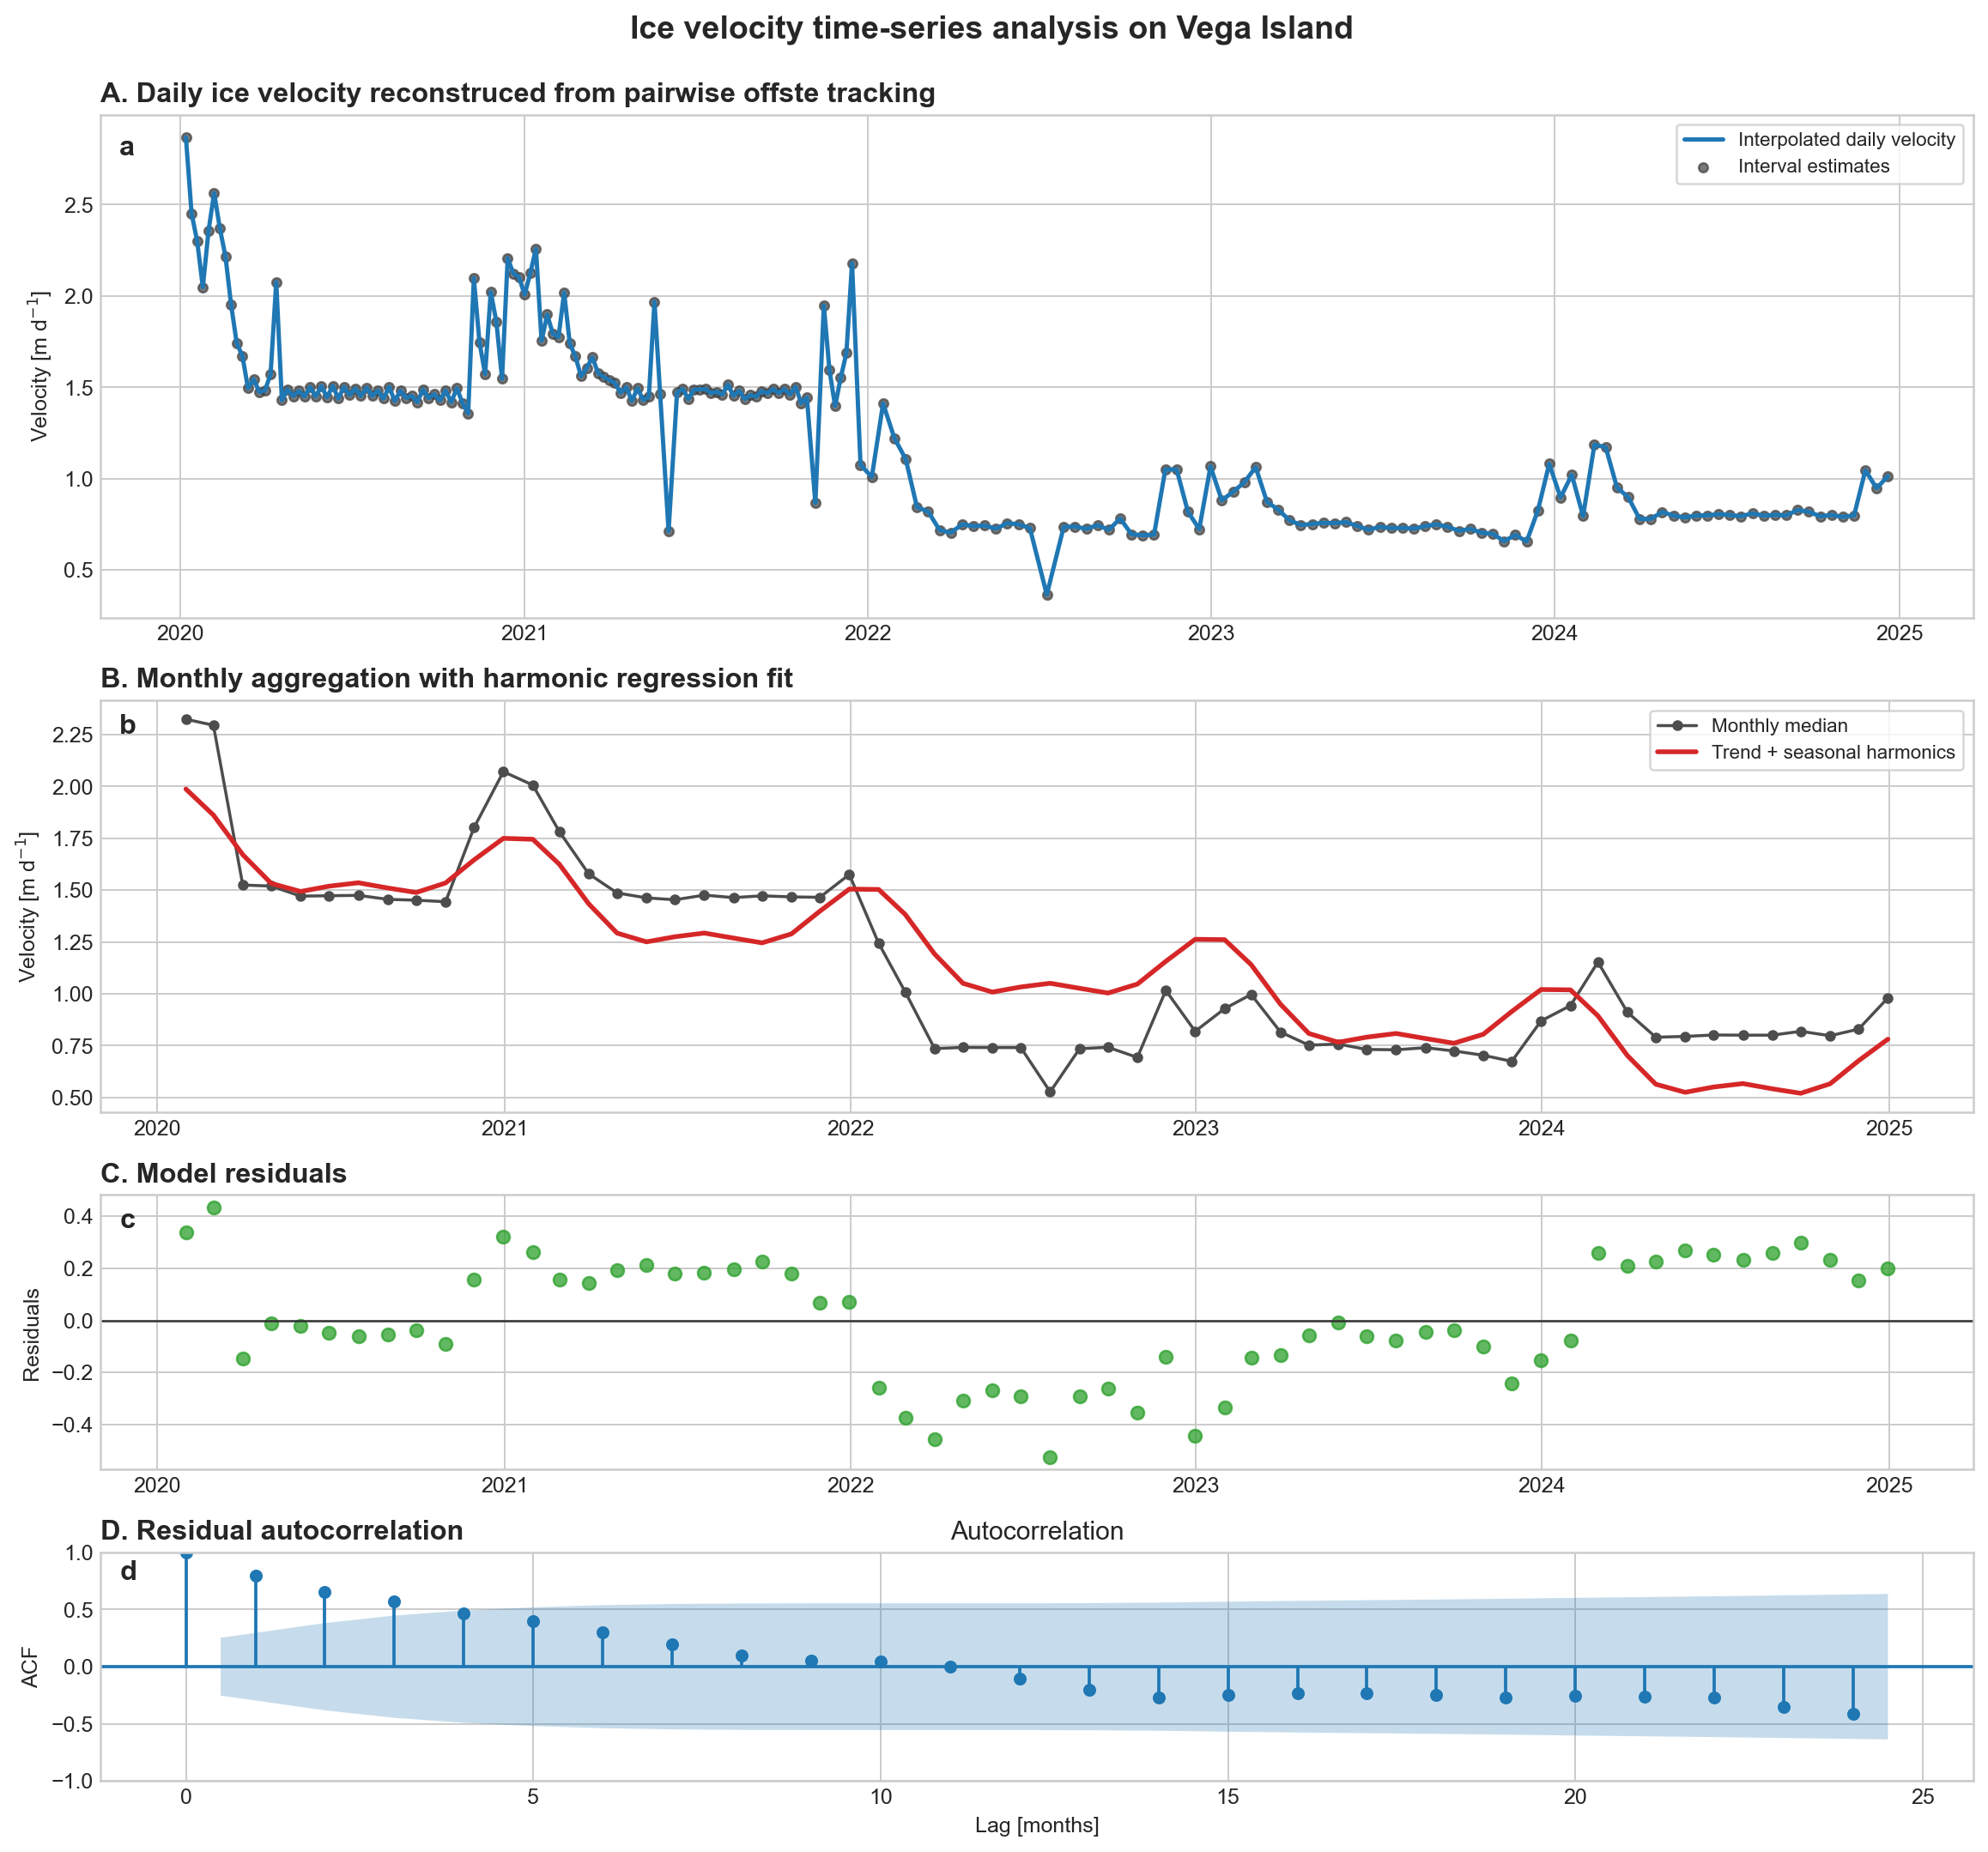

In [20]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    4, 1, figsize=(13, 12), dpi=180, sharex=False,
    gridspec_kw={"height_ratios": [2.2, 1.8, 1.2, 1.0]}
)

# A
ax = axes[0]
ax.plot(
    daily_velocity.index,
    daily_velocity.values,
    color="#1f77b4",
    lw=2.0,
    label="Interpolated daily velocity"
)
ax.scatter(
    velocity_series.index,
    velocity_series.values,
    s=18,
    color="0.25",
    alpha=.7,
    label="Interval estimates"
)

ax.set_title("A. Daily ice velocity reconstruced from pairwise offste tracking", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Velocity [m d$^{-1}$]")
ax.legend(frameon=True, fontsize=9)
ax.text(0.01, 0.92, "a", transform=ax.transAxes, fontsize=13, fontweight="bold")

#B
ax = axes[1]
ax.plot(
    monthly_df.index,
    monthly_df["monthly_velocity_m_day"],
    color="0.3",
    marker="o",
    ms=4,
    lw=1.4,
    label="Monthly median"
)

ax.plot(
    monthly_df.index,
    monthly_df["fit"],
    color="#d62728",
    lw=2.2,
    label="Trend + seasonal harmonics"
)
ax.set_title("B. Monthly aggregation with harmonic regression fit", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Velocity [m d$^{-1}$]")
ax.legend(frameon=True, fontsize=9)
ax.text(0.01, 0.92, "b", transform=ax.transAxes, fontsize=13, fontweight="bold")

# C
ax= axes[2]
ax.axhline(0, color="0.2", lw=1)
ax.scatter(
    monthly_df.index,
    monthly_df["resid"],
    color="#2ca02c",
    alpha=.75
)
ax.set_title("C. Model residuals", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Residuals")
ax.text(0.01, 0.88, "c", transform=ax.transAxes, fontsize=13, fontweight="bold")

# D
ax = axes[3]
resid = monthly_df["resid"].dropna().values
sm.graphics.tsa.plot_acf(resid, lags=min(24, len(resid) - 1), ax=ax, alpha=.05)
ax.set_title("D. Residual autocorrelation", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Lag [months]")
ax.set_ylabel("ACF")
ax.text(0.01, 0.88, "d", transform=ax.transAxes, fontsize=13, fontweight="bold")

fig.suptitle(
    "Ice velocity time-series analysis on Vega Island",
    fontsize=15, fontweight="bold", y=.995
)
fig.tight_layout()
plt.show()

seasonal decomposition

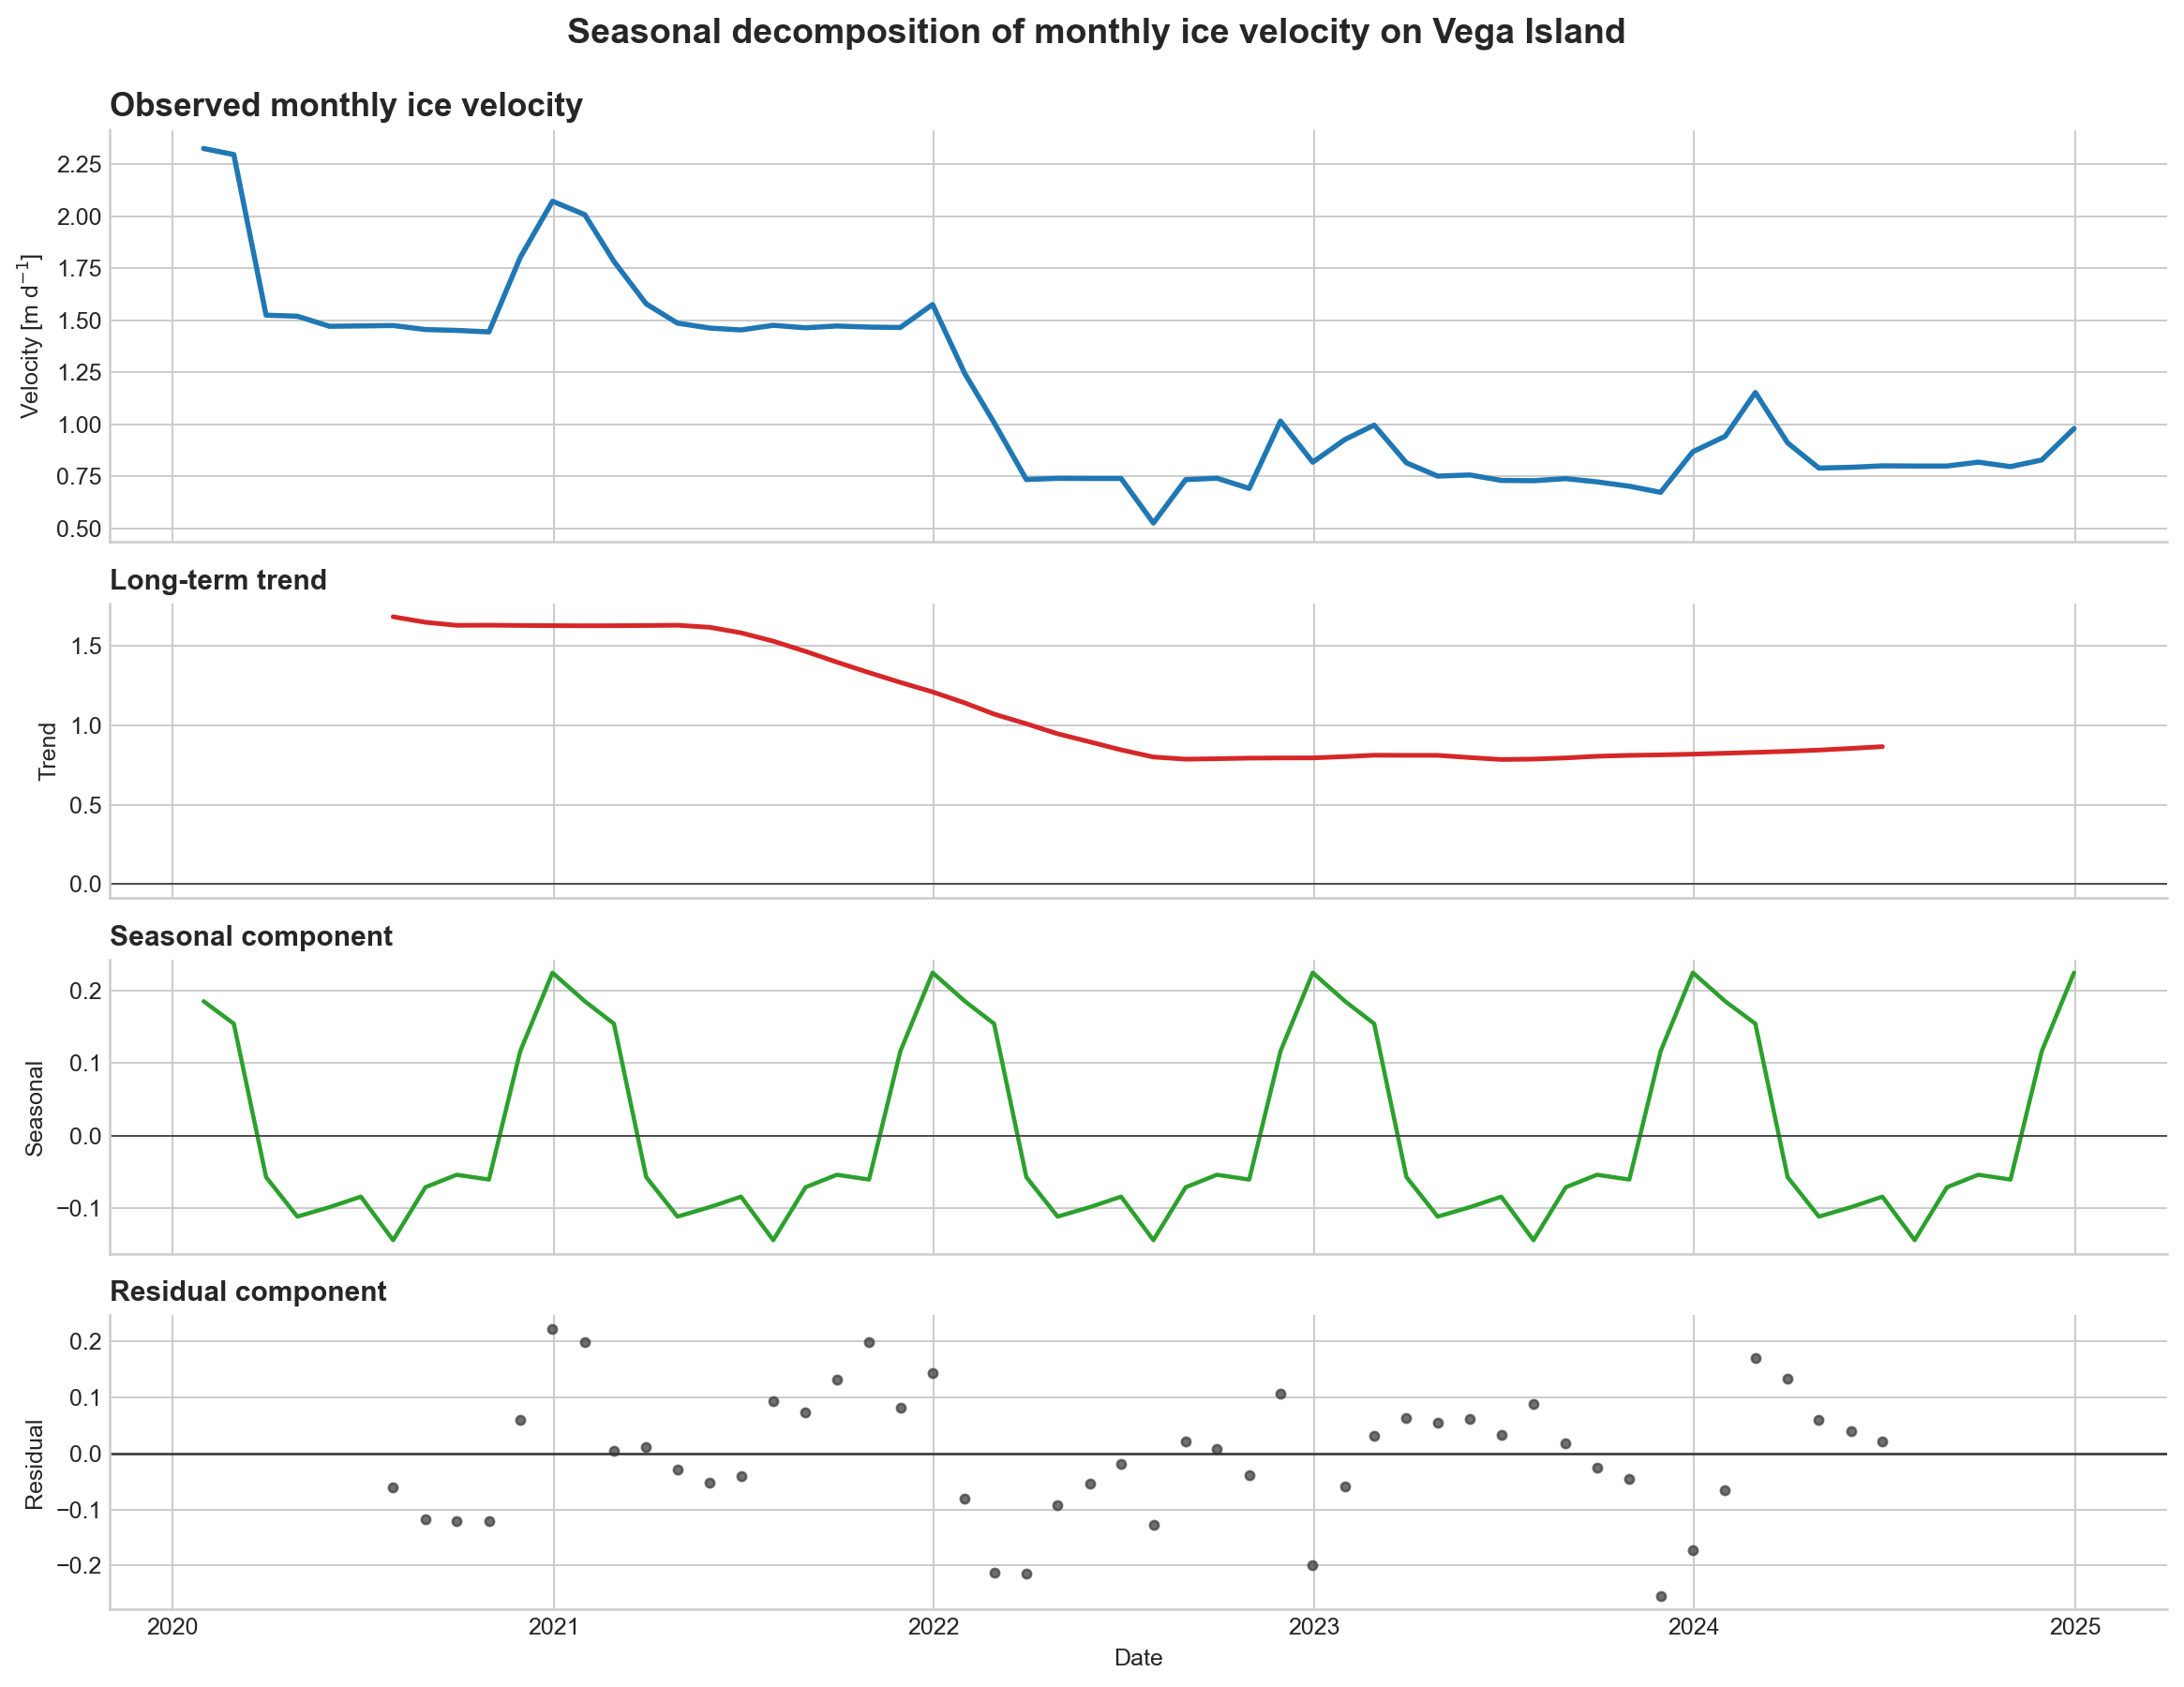

In [12]:
series = monthly_velocity.dropna()
decomp=sm.tsa.seasonal_decompose(
    series,
    model="additive",
    period=12
)

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    4, 1,
    figsize=(13, 10),
    dpi=180,
    sharex=True,
    gridspec_kw={"height_ratios": [1.4, 1.0, 1.0, 1.0]}
)

ax = axes[0]
ax.plot(
    series.index,
    series.values,
    color="#1f77b4",
    lw=2.2
)
ax.set_ylabel(r"Velocity [m d$^{-1}$]")
ax.set_title(
    "Observed monthly ice velocity",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax=axes[1]
ax.plot(
    decomp.trend.index,
    decomp.trend.values,
    color="#d62728",
    lw=2.0
)
ax.axhline(0, color="0.3", lw=0.8)
ax.set_ylabel("Trend")
ax.set_title("Long-term trend", loc="left", fontsize=12, fontweight="bold")

ax=axes[2]
ax.plot(
    decomp.seasonal.index,
    decomp.seasonal.values,
    color="#2ca02c",
    lw=1.8
)
ax.axhline(0, color="0.3", lw=0.8)
ax.set_ylabel("Seasonal")
ax.set_title("Seasonal component", loc="left", fontsize=12, fontweight="bold")

ax=axes[3]
ax.scatter(
    decomp.resid.index,
    decomp.resid.values,
    s=14,
    color="0.25",
    alpha=.75
)
ax.axhline(0, color="0.2", lw=1.0)
ax.set_ylabel("Residual")
ax.set_xlabel("Date")
ax.set_title("Residual component", loc="left", fontsize=12, fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=10)

fig.suptitle(
    "Seasonal decomposition of monthly ice velocity on Vega Island",
    fontsize=15, fontweight="bold", y=.995
)

fig.tight_layout()
plt.show()